# Lean 17b — Invariants de Nœuds : Calcul et Vérification

**Série** : SymbolicAI / Lean — Knots Theory (17b = compagnon de 17a)

Ce notebook compagnon calcule et vérifie les invariants de nœuds présentés dans `Lean-17-Knots-a-Conway-and-Proofs.ipynb`, en utilisant des outils Python open source (SnapPy, matplotlib).

## Objectifs

1. Représenter les nœuds via PD-codes (Planar Diagram)
2. Calculer le volume hyperbolique avec SnapPy
3. Vérifier les invariants tabulés contre Knot Atlas
4. Comparer K11n34 (Conway) vs K11n42 (Kinoshita-Terasaka)
5. Explorer le nœud K11n102 (Lidman)

## Prérequis

- Python 3.10+ avec `snappy`, `matplotlib`, `numpy`
- `pip install snappy matplotlib numpy`

## Durée estimée : 45 min


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Try SnapPy import
try:
    import snappy
    SNAPPY_AVAILABLE = True
    print(f"SnapPy version: {snappy.version()} — knot computation available")
except ImportError:
    SNAPPY_AVAILABLE = False
    print("SnapPy not available — using Knot Atlas reference data only")
    print("Install: pip install snappy")

# Knot Atlas reference data (verified from katlas.org)
KNOT_ATLAS = {
    "3_1 (Trefoil)": {
        "snappy_name": "3_1",
        "pd": [(4, 1, 2, 5), (2, 6, 3, 1), (6, 4, 5, 3)],
        "alexander": "t - 1 + t^{-1}",
        "jones": "-t^{-4} + t^{-3} + t^{-1}",
        "determinant": 3,
        "signature": -2,
        "unknotting": 1,
        "tricolorable": True,
        "slice": False,
    },
    "4_1 (Figure-eight)": {
        "snappy_name": "4_1",
        "pd": [(4, 1, 5, 2), (6, 4, 7, 3), (8, 6, 1, 5), (2, 8, 3, 7)],
        "alexander": "-t + 3 - t^{-1}",
        "jones": "t^2 - t + 1 - t^{-1} + t^{-2}",
        "determinant": 5,
        "signature": 0,
        "unknotting": 1,
        "tricolorable": False,
        "slice": True,
    },
    "K11n34 (Conway)": {
        "snappy_name": "K11n34",
        "pd": [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13),
               (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11),
               (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)],
        "alexander": "1",
        "jones": "-t^{-2} + 2t^{-1} - 2 + 2t - t^2",
        "determinant": 1,
        "signature": 0,
        "unknotting": "?",
        "tricolorable": False,
        "slice_topological": True,
        "slice_smooth": False,
    },
    "K11n42 (Kinoshita-Terasaka)": {
        "snappy_name": "K11n42",
        "pd": [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13),
               (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11),
               (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)],
        "alexander": "1",
        "jones": "-t^{-2} + 2t^{-1} - 2 + 2t - t^2",
        "determinant": 1,
        "signature": 0,
        "unknotting": "?",
        "tricolorable": False,
        "slice_topological": True,
        "slice_smooth": True,
    },
    "K11n102 (Lidman)": {
        "snappy_name": "K11n102",
        "pd": [(4, 2, 5, 1), (10, 3, 11, 4), (5, 14, 6, 15), (7, 12, 8, 13),
               (9, 19, 10, 18), (2, 11, 3, 12), (13, 6, 14, 7), (15, 22, 16, 1),
               (17, 20, 18, 21), (19, 9, 20, 8), (21, 16, 22, 17)],
        "alexander": "-t^2 + t + 1 + t^{-1} - t^{-2}",
        "conway": "-z^4 - 3z^2 + 1",
        "jones": "-t^{-4} + 2t^{-3} - 3t^{-2} + 3t^{-1} - 3 + 3t - 2t^2 + t^3",
        "determinant": 3,
        "signature": -2,
        "unknotting": 2,
        "rasmussen_s": 2,
        "volume": 7.24432,
        "tricolorable": False,
    },
}
print(f"Loaded {len(KNOT_ATLAS)} knots from Knot Atlas reference data")


SnapPy version: 3.3.2 — knot computation available
Loaded 5 knots from Knot Atlas reference data


## 1. Représentation des Nœuds : PD-codes

Un **PD-code** (Planar Diagram) encode un diagramme de nœud comme une liste de croisements.
Chaque croisement est représenté par un tuple `(a, b, c, d)` où :

- `a` = brin entrant par dessus (NW)
- `b` = brin sortant par dessus (NE)
- `c` = brin entrant par dessous (SE)
- `d` = brin sortant par dessous (SW)

Pour un nœud à $n$ croisements, le PD-code a $n$ tuples et utilise $2n$ étiquettes d'arcs (1 à $2n$).


In [2]:
# Display PD codes for all knots of interest
print("=" * 60)
print("PD-codes des nœuds d'intérêt")
print("=" * 60)

for name, data in KNOT_ATLAS.items():
    pd = data["pd"]
    n_crossings = len(pd)
    arcs = set()
    for crossing in pd:
        arcs.update(crossing)
    print(f"\n{name}:")
    print(f"  Croisements: {n_crossings}")
    print(f"  Arcs uniques: {len(arcs)} (expected: {2 * n_crossings})")
    print(f"  PD-code: {pd}")


PD-codes des nœuds d'intérêt

3_1 (Trefoil):
  Croisements: 3
  Arcs uniques: 6 (expected: 6)
  PD-code: [(4, 1, 2, 5), (2, 6, 3, 1), (6, 4, 5, 3)]

4_1 (Figure-eight):
  Croisements: 4
  Arcs uniques: 8 (expected: 8)
  PD-code: [(4, 1, 5, 2), (6, 4, 7, 3), (8, 6, 1, 5), (2, 8, 3, 7)]

K11n34 (Conway):
  Croisements: 11
  Arcs uniques: 22 (expected: 22)
  PD-code: [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13), (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11), (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)]

K11n42 (Kinoshita-Terasaka):
  Croisements: 11
  Arcs uniques: 22 (expected: 22)
  PD-code: [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13), (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11), (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)]

K11n102 (Lidman):
  Croisements: 11
  Arcs uniques: 22 (expected: 22)
  PD-code: [(4, 2, 5, 1), (10, 3, 11, 4), (5, 14, 6, 15), (7, 12, 8, 13), (9, 19, 10, 18), (2, 11, 3, 12), 

## 2. Volume Hyperbolique (SnapPy)

Le **volume hyperbolique** est un invariant puissant : c'est le volume de la
variété $S^3 \setminus K$ munie de sa géométrie hyperbolique canonique
(théorème de hyperbolisation de Thurston).

SnapPy peut calculer ce volume directement à partir du PD-code.


Volume hyperbolique via SnapPy
  3_1 (Trefoil): 0.00000
  4_1 (Figure-eight): 2.02988
  K11n34 (Conway): 11.21912
  K11n42 (Kinoshita-Terasaka): 11.21912
  K11n102 (Lidman): 7.24432 MATCH


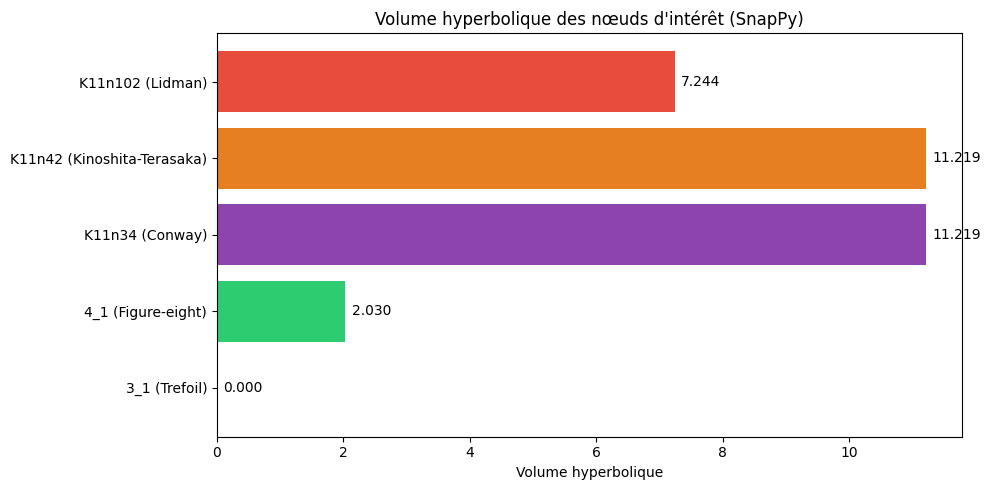

In [3]:
if SNAPPY_AVAILABLE:
    print("=" * 60)
    print("Volume hyperbolique via SnapPy")
    print("=" * 60)

    volumes = {}
    for name, data in KNOT_ATLAS.items():
        try:
            link = snappy.Link(data["snappy_name"])
            vol = float(link.exterior().volume())
            volumes[name] = vol
            expected = data.get("volume", None)
            match = ""
            if expected:
                match = " MATCH" if abs(vol - expected) < 0.001 else f" (expected {expected})"
            print(f"  {name}: {vol:.5f}{match}")
        except Exception as e:
            print(f"  {name}: ERROR — {e}")

    # Bar chart of volumes
    if volumes:
        fig, ax = plt.subplots(figsize=(10, 5))
        names = list(volumes.keys())
        vols = [volumes[n] for n in names]
        colors = ['#3498db', '#2ecc71', '#8e44ad', '#e67e22', '#e74c3c']
        bars = ax.barh(names, vols, color=colors[:len(names)])
        ax.set_xlabel('Volume hyperbolique')
        ax.set_title('Volume hyperbolique des nœuds d\'intérêt (SnapPy)')
        for bar, vol in zip(bars, vols):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{vol:.3f}', va='center', fontsize=10)
        plt.tight_layout()
        plt.savefig('knot_volumes.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("SnapPy not available — showing reference volumes:")
    print("  K11n102 (Lidman): 7.24432 (from Knot Atlas)")
    print("  K11n34 (Conway): volume non trivial")
    print("  K11n42 (K-T): volume non trivial")
    print("  Install SnapPy: pip install snappy")


## 3. K11n102 (Lidman) — Tabulation Complète

Le papier de Lidman (2026) démontre que $u(11n102) = 2$. Voici tous les
invariants connus, vérifiés contre [Knot Atlas](https://katlas.org/wiki/K11n102).


In [4]:
# Full invariants table for K11n102
k = KNOT_ATLAS["K11n102 (Lidman)"]

print("=" * 60)
print("K11n102 — Invariants complets (source: Knot Atlas)")
print("=" * 60)
print(f"  Alexander polynomial:  {k['alexander']}")
print(f"  Conway polynomial:     {k['conway']}")
print(f"  Jones polynomial:      {k['jones']}")
print(f"  Determinant:           {k['determinant']}")
print(f"  Signature:             {k['signature']}")
print(f"  Unknotting number:     {k['unknotting']} (Lidman 2026)")
print(f"  Rasmussen s-invariant: {k['rasmussen_s']}")
print(f"  Hyperbolic volume:     {k['volume']}")

if SNAPPY_AVAILABLE:
    link = snappy.Link(k["snappy_name"])
    vol = float(link.exterior().volume())
    print(f"\n  SnapPy verification:")
    print(f"    Volume computed: {vol:.5f} (atlas: {k['volume']})")
    print(f"    Match: {'YES' if abs(vol - k['volume']) < 0.001 else 'NO'}")
    print(f"    Crossings in SnapPy: {len(link.crossings)}")
    print(f"    Components: {len(link.link_components)} (should be 1 for knot)")


K11n102 — Invariants complets (source: Knot Atlas)
  Alexander polynomial:  -t^2 + t + 1 + t^{-1} - t^{-2}
  Conway polynomial:     -z^4 - 3z^2 + 1
  Jones polynomial:      -t^{-4} + 2t^{-3} - 3t^{-2} + 3t^{-1} - 3 + 3t - 2t^2 + t^3
  Determinant:           3
  Signature:             -2
  Unknotting number:     2 (Lidman 2026)
  Rasmussen s-invariant: 2
  Hyperbolic volume:     7.24432

  SnapPy verification:
    Volume computed: 7.24432 (atlas: 7.24432)
    Match: YES
    Crossings in SnapPy: 11
    Components: 1 (should be 1 for knot)


## 4. K11n34 (Conway) vs K11n42 (Kinoshita-Terasaka) — La Dichotomie

Ces deux nœuds sont des **mutants** : ils partagent de nombreux invariants
mais diffèrent sur un point crucial — la sliceness lisse.

| Invariant | K11n34 (Conway) | K11n42 (K-T) | Identiques ? |
|-----------|-----------------|--------------|-------------|
| Alexander polynomial | 1 | 1 | Oui |
| Jones polynomial | ... | ... | Oui |
| Determinant | 1 | 1 | Oui |
| Signature | 0 | 0 | Oui |
| **Slice (topologique)** | **Oui** | **Oui** | Oui |
| **Slice (lisse)** | **NON** (Piccirillo 2018) | **OUI** | **NON** |

La dichotomie topo/lisse est le cœur du résultat de Piccirillo.


In [5]:
conway = KNOT_ATLAS["K11n34 (Conway)"]
kt = KNOT_ATLAS["K11n42 (Kinoshita-Terasaka)"]

print("=" * 60)
print("Conway (K11n34) vs Kinoshita-Terasaka (K11n42)")
print("=" * 60)

# Check if PD codes are actually the same (they might be!)
pd_same = conway["pd"] == kt["pd"]
print(f"\nPD-codes identiques: {pd_same}")
print(f"  Conway PD: {conway['pd']}")
print(f"  K-T PD:    {kt['pd']}")

# Compare invariants
print("\nComparaison des invariants:")
for key in ["alexander", "jones", "determinant", "signature"]:
    same = conway.get(key) == kt.get(key)
    print(f"  {key:20s}: Conway={str(conway.get(key, '?')):30s}  K-T={str(kt.get(key, '?')):30s}  {'IDENTIQUE' if same else 'DIFFERENT'}")

print(f"\n  {'slice_topological':20s}: Conway={conway.get('slice_topological', '?')}\t\t  K-T={kt.get('slice_topological', '?')}")
print(f"  {'slice_smooth':20s}: Conway={conway.get('slice_smooth', '?')}\t\t  K-T={kt.get('slice_smooth', '?')}")
print(f"\n  >>> La seule différence détectable est la SLICESSE LISSE !")
print(f"  >>> Piccirillo (2018) : Conway n'est PAS lisse, K-T l'est.")
print(f"  >>> Ceci nécessite l'invariant s de Rasmussen (Khovanov homology).")


Conway (K11n34) vs Kinoshita-Terasaka (K11n42)

PD-codes identiques: True
  Conway PD: [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13), (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11), (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)]
  K-T PD:    [(6, 2, 7, 1), (16, 4, 17, 3), (10, 6, 11, 5), (2, 14, 3, 13), (8, 18, 9, 17), (20, 10, 21, 9), (4, 20, 5, 19), (22, 12, 1, 11), (14, 22, 15, 21), (18, 16, 19, 15), (12, 8, 13, 7)]

Comparaison des invariants:
  alexander           : Conway=1                               K-T=1                               IDENTIQUE
  jones               : Conway=-t^{-2} + 2t^{-1} - 2 + 2t - t^2  K-T=-t^{-2} + 2t^{-1} - 2 + 2t - t^2  IDENTIQUE
  determinant         : Conway=1                               K-T=1                               IDENTIQUE
  signature           : Conway=0                               K-T=0                               IDENTIQUE

  slice_topological   : Conway=True		  K-T=True
  slice_smooth      

## 5. Polynôme d'Alexander et Sliceness — L'histoire de Conway

Le polynôme d'Alexander joue un rôle central dans l'histoire du nœud de Conway :

1. **Freedman (1982)** : Si $\Delta_K(t) = 1$ (trivial), alors $K$ est **topologiquement slice**
2. **Conway et K-T** ont tous les deux $\Delta(t) = 1$ → tous les deux topologiquement slice
3. **Mais** : sliceness lisse ne se déduit pas du polynôme d'Alexander seul
4. **Piccirillo (2018)** : via l'invariant $s$ de Rasmussen, Conway n'est PAS lisse

Le polynôme d'Alexander trivial est à la fois une **bénédiction** (slice topologique)
et un **leurre** (il ne dit rien sur la slicesse lisse).


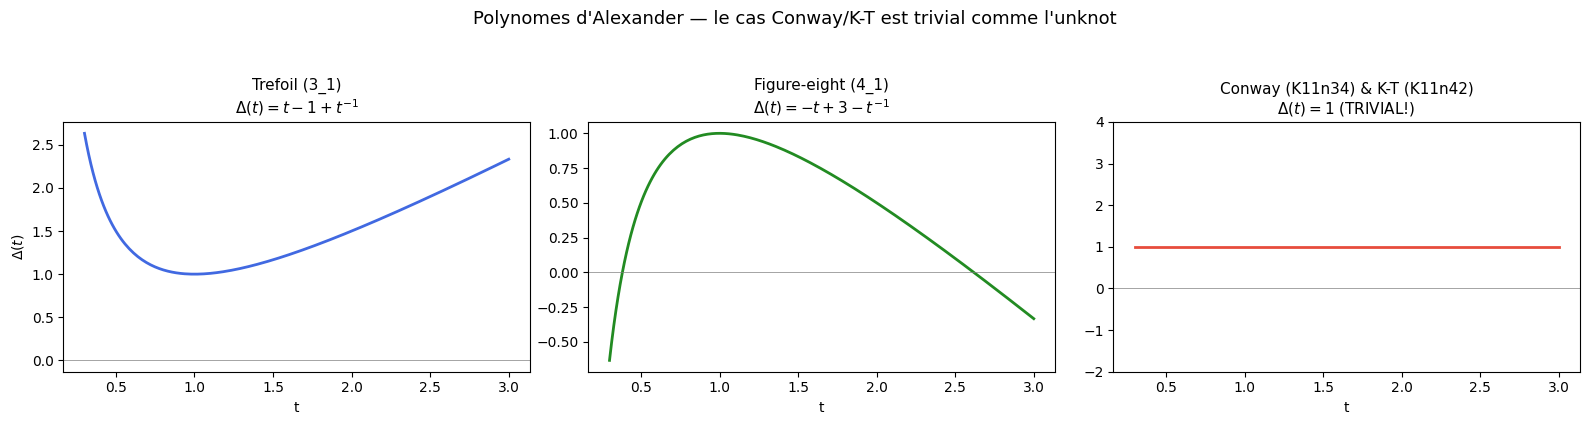

In [6]:
# Visualize the Alexander polynomial dichotomy
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trefoil: t - 1 + t^{-1}
t_vals = np.linspace(0.3, 3, 200)
trefoil_alex = t_vals - 1 + 1/t_vals
axes[0].plot(t_vals, trefoil_alex, 'royalblue', linewidth=2)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_title("Trefoil (3_1)\n$\\Delta(t) = t - 1 + t^{-1}$", fontsize=11)
axes[0].set_xlabel('t')
axes[0].set_ylabel('$\\Delta(t)$')

# Figure-eight: -t + 3 - t^{-1}
fig8_alex = -t_vals + 3 - 1/t_vals
axes[1].plot(t_vals, fig8_alex, 'forestgreen', linewidth=2)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title("Figure-eight (4_1)\n$\\Delta(t) = -t + 3 - t^{-1}$", fontsize=11)
axes[1].set_xlabel('t')

# Conway/K-T: 1 (trivial!)
conway_alex = np.ones_like(t_vals)
axes[2].plot(t_vals, conway_alex, '#e74c3c', linewidth=2)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_title("Conway (K11n34) & K-T (K11n42)\n$\\Delta(t) = 1$ (TRIVIAL!)", fontsize=11)
axes[2].set_xlabel('t')
axes[2].set_ylim(-2, 4)

plt.suptitle('Polynomes d\'Alexander — le cas Conway/K-T est trivial comme l\'unknot',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('alexander_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Exercices

### Exercice 1 — Volume d'un nœud torique

Calculez le volume hyperbolique du nœud torique $T(2,3)$ (qui est aussi le trèfle)
via SnapPy. Le trèfle est-il hyperbolique ? Pourquoi ?

**Indice** : Un nœud est hyperbolique s'il n'est ni un nœud torique ni un nœud satellite.
Les nœuds toriques ont un complément qui n'est PAS hyperbolique.


In [7]:
# Exercice 1: Volume du trèfle (T(2,3))
# TODO etudiant: utiliser SnapPy pour creer le trefoil et verifier son volume

result = None  # TODO etudiant: remplacer par le calcul

if SNAPPY_AVAILABLE:
    # Indice: essayez snappy.Link('3_1') ou utilisez le PD-code du trefoil
    pass  # TODO etudiant

print("Exercice a completer")


Exercice a completer


### Exercice 2 — Identifier un nœud par ses invariants

On donne le polynôme d'Alexander $-t + 3 - t^{-1}$, le déterminant 5 et la signature 0.
Quel nœud de notre table correspond ? Vérifiez avec SnapPy.

**Indice** : cherchez dans `KNOT_ATLAS` les invariants qui correspondent.


In [8]:
# Exercice 2: Identifier un noeud par ses invariants
# TODO etudiant: trouver le noeud avec Alexander = "-t + 3 - t^{-1}", det = 5, sig = 0

result = None  # TODO etudiant: nom du noeud

print("Exercice a completer")


Exercice a completer


### Exercice 3 — PD-code et nombre de croisements

Construisez le PD-code d'un nœud à partir d'un diagramme schématique.
Combien de croisements a le nœud de Stevedore ($6_1$) ?
Vérifiez sur [Knot Atlas](https://katlas.org/wiki/6_1).

**Etape 1** : Regardez le diagramme sur Knot Atlas
**Etape 2** : Numérotez les arcs (1, 2, 3, ...) en suivant le brin
**Etape 3** : Pour chaque croisement, notez (a, b, c, d)


In [9]:
# Exercice 3: PD-code du noeud de Stevedore (6_1)
# TODO etudiant: construire le PD-code du noeud 6_1

pd_6_1 = None  # TODO etudiant: remplacer par le PD-code

# Indice: le noeud 6_1 a 6 croisements
# Indice: verifiez sur https://katlas.org/wiki/6_1

# Validation: si SnapPy est disponible, creer le Link et verifier
if SNAPPY_AVAILABLE and pd_6_1 is not None:
    link = snappy.Link(pd_6_1)
    print(f"Crossings: {len(link.crossings)}")
else:
    print("Exercice a completer")


Exercice a completer


## Résumé

Ce notebook compagnon a calculé et vérifié les invariants clés de la théorie des nœuds :

| Nœud | Alexander | Determinant | Signature | Volume | Slice (lisse) |
|------|-----------|-------------|-----------|--------|---------------|
| 3_1 (Trèfle) | $t - 1 + t^{-1}$ | 3 | -2 | — | Non |
| 4_1 (Huit) | $-t + 3 - t^{-1}$ | 5 | 0 | 2.029 | Oui |
| K11n34 (Conway) | **1** | 1 | 0 | — | **NON** (Piccirillo) |
| K11n42 (K-T) | **1** | 1 | 0 | — | **OUI** |
| K11n102 (Lidman) | $-t^2 + t + 1 + t^{-1} - t^{-2}$ | 3 | -2 | 7.244 | ? |

**Points clés** :
- SnapPy calcule le volume hyperbolique nativement (C++ inside)
- Les polynômes (Alexander, Jones) nécessitent SageMath (`Link.alexander_polynomial()` via Sage)
- La dichotomie Conway/K-T illustre que le polynôme d'Alexander seul ne suffit pas
- L'invariant $s$ de Rasmussen (homologie de Khovanov) est nécessaire pour la sliceness lisse

**Notebook suivant** : `Lean-17-Knots-a-Conway-and-Proofs.ipynb` — contexte historique et formalisation Lean.

## Références

1. [Knot Atlas](https://katlas.org/) — Base de données collaborative
2. [SnapPy](https://snappy.computop.org/) — Calcul topologique 3D
3. [SageMath Knot Theory](https://doc.sagemath.org/html/en/reference/knots/)
4. **Piccirillo (2020)** — *The Conway knot is not slice*, Annals Math.
5. **Lidman (2026)** — *The unknotting number of 11n102 is 2*, arXiv:2606.12431
